In [1]:
import os
os.makedirs('config', exist_ok=True)


In [2]:
%%writefile config/u-net.yaml
dataset_params:
  train_im_sets: ['data/oxford_pets']
  test_im_sets: ['data/oxford_pets_test']
  num_classes: 3
  im_size: 128

model:
  name: "UNet"
  input:
    shape: [3, 128, 128]

  output:
    classes: 3
    activation: "none"
    shape: [3, 128, 128]

  encoder:
    block:
      - layer:
          filters: 64
          kernel_size: 3
          batch_norm: True
          activation: "relu"
          repeat: 2
          output_name: "s1"
        pool: "max"
      - layer:
          filters: 128
          kernel_size: 3
          batch_norm: True
          activation: "relu"
          repeat: 2
          output_name: "s2"
        pool: "max"
      - layer:
          filters: 256
          kernel_size: 3
          batch_norm: True
          activation: "relu"
          repeat: 2
          output_name: "s3"
        pool: "max"
      - layer:
          filters: 512
          kernel_size: 3
          batch_norm: True
          activation: "relu"
          repeat: 2
          output_name: "s4"
        pool: "max"

  bottleneck:
    layer:
      filters: 1024
      kernel_size: 3
      batch_norm: True
      activation: "relu"
      repeat: 2

  decoder:
    block:
      - layer:
          filters: 512
          kernel_size: 3
          batch_norm: True
          activation: "relu"
          repeat: 2
          upsample: True
          scale_factor: 2
          concat: "s4"
      - layer:
          filters: 256
          kernel_size: 3
          batch_norm: True
          activation: "relu"
          repeat: 2
          upsample: True
          scale_factor: 2
          concat: "s3"
      - layer:
          filters: 128
          kernel_size: 3
          batch_norm: True
          activation: "relu"
          repeat: 2
          upsample: True
          scale_factor: 2
          concat: "s2"
      - layer:
          filters: 64
          kernel_size: 3
          batch_norm: True
          activation: "relu"
          repeat: 2
          upsample: True
          scale_factor: 2
          concat: "s1"

  OUTPUT:
    block:
      layer:
        filters: 3
        kernel_size: 1

train_params:
  task_name: 'unet_oxford_pets'
  seed: 1111
  acc_steps: 1
  num_epochs: 60
  batch_size: 8
  lr_steps: [40, 50]
  lr: 0.001
  log_steps: 100


Overwriting config/u-net.yaml


In [3]:
import os
import random
import argparse
import numpy as np
import yaml

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import MultiStepLR
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import tv_tensors
from torchvision.transforms import v2

import matplotlib.pyplot as plt


In [ ]:
def load_image(split='train'):
    ds_split = "trainval" if split == "train" else "test"
    dataset = torchvision.datasets.OxfordIIITPet(
        root="./data",
        split=ds_split,
        target_types="segmentation",
        download=True,
    )
    return dataset


class OxfordPetsDataset(Dataset):
    def __init__(self, im_size=128, split='train', num_classes=3):
        self.im_size = im_size
        self.split = split
        self.num_classes = num_classes
        self.dataset = load_image(split)

        self.image_resize = v2.Resize((im_size, im_size))
        self.mask_resize = v2.Resize((im_size, im_size), interpolation=v2.InterpolationMode.NEAREST)
        self.to_dtype_mask = v2.ToDtype(torch.int64, scale=False)

        self.photometric_distort = v2.RandomPhotometricDistort(p=0.5)

        # self.random_zoom = v2.RandomAffine(
        #     degrees=0,
        #     scale=(0.8, 1.2),
        #     fill=(0, 2)   
        # )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]
        image = tv_tensors.Image(image)
        mask = tv_tensors.Mask(mask)

        # Resize
        image = self.image_resize(image)
        mask = self.mask_resize(mask)

        if self.split == 'train':
            if torch.rand(1).item() > 0.5:
                image = v2.functional.hflip(image)
                mask = v2.functional.hflip(mask)

            # image, mask = self.random_zoom(image, mask)
            image = self.photometric_distort(image)

        image = image.float() / 255.0

        mask = self.to_dtype_mask(mask)
        mask = mask.squeeze(0)
        mask = mask - 1
        # mask = torch.clamp(mask, 0, 2)

        return image, mask

    def viz(self, img, mask):
        img_np = img.permute(1, 2, 0).cpu().numpy()
        img_np = np.clip(img_np, 0, 1)

        mask_np = mask.cpu().numpy()
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(img_np)
        axes[0].set_title("Image")
        axes[1].imshow(mask_np, cmap='gray', vmin=0, vmax=2)
        axes[1].set_title("Mask (0=pet, 1=bg, 2=border)")
        axes[2].imshow(img_np)
        axes[2].imshow(mask_np, cmap='jet', alpha=0.5, vmin=0, vmax=2)
        axes[2].set_title("Overlay")
        plt.show()

In [ ]:
class UNET(nn.Module):
    def __init__(self, config_path):
        super().__init__()
        with open(config_path, 'r') as f:
            config = yaml.safe_load(f)
        self.model_config = config['model']

        self.input_shape = self.model_config['input']['shape']
        self.num_classes = self.model_config['output']['classes']
        self.output_activation = self.model_config['output']['activation']

        self.build_encoder()
        self.build_bottleneck()
        self.build_decoder()
        self.build_output()

        self.criterion = nn.CrossEntropyLoss()

    def build_encoder(self):
        self.encoders = nn.ModuleList()
        self.pools = nn.ModuleList()
        self.skip_names = []
        self.skip_channels = []

        prev_ch = self.input_shape[0]
        blocks = self.model_config['encoder']['block']
        if not isinstance(blocks, list):
            blocks = [blocks]

        for block_cfg in blocks:
            layer_cfg = block_cfg['layer']
            filters = layer_cfg['filters']
            repeat = layer_cfg.get('repeat', 2)

            layers = []
            for i in range(repeat):
                in_ch = prev_ch if i == 0 else filters
                layers.append(
                    nn.Conv2d(in_ch, filters,
                              kernel_size=layer_cfg.get('kernel_size', 3),
                              padding=layer_cfg.get('padding', 1))
                )
                if layer_cfg.get('batch_norm', True):
                    layers.append(nn.BatchNorm2d(filters))
                if layer_cfg.get('activation', 'relu') == 'relu':
                    layers.append(nn.ReLU(inplace=True))

            self.encoders.append(nn.Sequential(*layers))
            self.skip_names.append(layer_cfg.get('output_name', None))
            self.skip_channels.append(filters)

            # Pooling
            pool_type = block_cfg.get('pool', 'max')
            if pool_type == 'max':
                self.pools.append(nn.MaxPool2d(kernel_size=2, stride=2))
            else:
                self.pools.append(nn.Identity())

            prev_ch = filters

    def build_bottleneck(self):
        bottle_cfg = self.model_config.get('bottleneck', {})
        layer_cfg = bottle_cfg.get('layer', {})
        in_ch = self.skip_channels[-1]  
        filters = layer_cfg.get('filters', 1024)
        repeat = layer_cfg.get('repeat', 2)

        layers = []
        for i in range(repeat):
            ch_in = in_ch if i == 0 else filters
            layers.append(
                nn.Conv2d(ch_in, filters,
                          kernel_size=layer_cfg.get('kernel_size', 3),
                          padding=layer_cfg.get('padding', 1))
            )
            if layer_cfg.get('batch_norm', True):
                layers.append(nn.BatchNorm2d(filters))
            if layer_cfg.get('activation', 'relu') == 'relu':
                layers.append(nn.ReLU(inplace=True))

        self.bottleneck = nn.Sequential(*layers)
        self.bottleneck_out_ch = filters

    def build_decoder(self):
        self.upconvs = nn.ModuleList()
        self.decoders = nn.ModuleList()
        self.decoder_skip_names = []

        prev_ch = self.bottleneck_out_ch
        blocks = self.model_config['decoder']['block']
        if not isinstance(blocks, list):
            blocks = [blocks]

        for block_cfg in blocks:
            layer_cfg = block_cfg['layer']
            filters = layer_cfg['filters']
            upsample = layer_cfg.get('upsample', False)
            scale = layer_cfg.get('scale_factor', 2)
            concat_name = layer_cfg.get('concat', None)

            if not upsample:
                continue

            # Upconvolution
            self.upconvs.append(
                nn.ConvTranspose2d(prev_ch, filters,
                                   kernel_size=scale, stride=scale)
            )
            self.decoder_skip_names.append(concat_name)

            # skip channel count from encoder
            skip_ch = 0
            if concat_name in self.skip_names:
                idx = self.skip_names.index(concat_name)
                skip_ch = self.skip_channels[idx]

            # Decoder conv block
            in_ch = filters + skip_ch
            repeat = layer_cfg.get('repeat', 2)

            layers = []
            for i in range(repeat):
                ch_in = in_ch if i == 0 else filters
                layers.append(
                    nn.Conv2d(ch_in, filters,
                              kernel_size=layer_cfg.get('kernel_size', 3),
                              padding=layer_cfg.get('padding', 1))
                )
                if layer_cfg.get('batch_norm', True):
                    layers.append(nn.BatchNorm2d(filters))
                if layer_cfg.get('activation', 'relu') == 'relu':
                    layers.append(nn.ReLU(inplace=True))

            self.decoders.append(nn.Sequential(*layers))
            prev_ch = filters

        if len(self.decoders) > 0:
            self.decoder_out_ch = filters
        else:
            self.decoder_out_ch = prev_ch

    def build_output(self):
        out_cfg = self.model_config.get('OUTPUT', {})
        block_cfg = out_cfg.get('block', {})
        layer_cfg = block_cfg.get('layer', {})
        out_ch = layer_cfg.get('filters', self.num_classes)
        kernel = layer_cfg.get('kernel_size', 1)

        self.final_conv = nn.Conv2d(
            in_channels=self.decoder_out_ch,
            out_channels=out_ch,
            kernel_size=kernel
        )

    def forward(self, x):
        skip_connections = {}

        # Encoder
        for i, (encoder, pool) in enumerate(zip(self.encoders, self.pools)):
            x = encoder(x)
            skip_name = self.skip_names[i]
            skip_connections[skip_name] = x
            x = pool(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder
        for i, (upconv, decoder) in enumerate(zip(self.upconvs, self.decoders)):
            x = upconv(x)
            skip_name = self.decoder_skip_names[i]
            if skip_name and skip_name in skip_connections:
                skip = skip_connections[skip_name]
                if x.shape[2:] != skip.shape[2:]:
                    x = F.interpolate(x, size=skip.shape[2:],
                                      mode='bilinear', align_corners=False)
                x = torch.cat([skip, x], dim=1)
            x = decoder(x)

        x = self.final_conv(x)
        return x

    @torch.no_grad()
    def predict(self, image, device=None):
        self.eval()
        if device is None:
            device = next(self.parameters()).device

        single = image.dim() == 3
        if single:
            image = image.unsqueeze(0)

        image = image.to(device)
        logits = self.forward(image)
        pred = torch.argmax(logits, dim=1)

        if single:
            pred = pred.squeeze(0)

        return pred

    def compute_loss(self, pred, target):
        target = target.long()
        return self.criterion(pred, target)


In [ ]:
def train(args):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if torch.backends.mps.is_available():
        device = torch.device('mps')
        print('Using MPS')

    with open(args.config_path, 'r') as f:
        config = yaml.safe_load(f)

    train_config = config['train_params']
    seed = train_config['seed']
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if device.type == 'cuda':
        torch.cuda.manual_seed_all(seed)

    # Dataset & DataLoader
    dataset = OxfordPetsDataset(
        im_size=config['dataset_params']['im_size'],
        split='train',
        num_classes=config['model']['output']['classes']
    )
    train_loader = DataLoader(
        dataset,
        batch_size=train_config['batch_size'],
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    # Model
    model = UNET(args.config_path).to(device)

    # Optimizer & Scheduler
    optimizer = optim.Adam(model.parameters(), lr=train_config['lr'])
    scheduler = MultiStepLR(optimizer,
                            milestones=train_config['lr_steps'],
                            gamma=0.5)

    acc_steps = train_config['acc_steps']
    num_epochs = train_config['num_epochs']
    log_steps = train_config['log_steps']

    checkpoint_dir = 'checkpoints'
    os.makedirs(checkpoint_dir, exist_ok=True)
    latest_ckpt_path = os.path.join(checkpoint_dir, 'latest_unet.pth')

    start_epoch = 0
    steps = 0

    # Resume if checkpoint exists
    if os.path.exists(latest_ckpt_path):
        checkpoint = torch.load(latest_ckpt_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        steps = checkpoint['steps']
        print(f"Resumed from checkpoint at epoch {start_epoch}")

    for epoch in range(start_epoch, num_epochs):
        model.train()
        epoch_loss = 0.0
        optimizer.zero_grad()

        for batch_idx, (images, targets) in enumerate(train_loader):
            images = images.to(device)
            targets = targets.to(device)

            preds = model(images)
            loss = model.compute_loss(preds, targets)

            loss = loss / acc_steps
            loss.backward()
            epoch_loss += loss.item() * acc_steps

            if (batch_idx + 1) % acc_steps == 0:
                optimizer.step()
                optimizer.zero_grad()

            steps += 1
            if steps % log_steps == 0:
                print(f"Epoch {epoch} | Step {steps} | Loss: {loss.item()*acc_steps:.4f}")

        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch} finished. Avg loss: {avg_loss:.4f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'steps': steps,
            'avg_loss': avg_loss
        }
        torch.save(checkpoint, latest_ckpt_path)

        if (epoch + 1) % 10 == 0:
            epoch_ckpt = os.path.join(checkpoint_dir, f'epoch_{epoch+1}.pth')
            torch.save(checkpoint, epoch_ckpt)
            print(f"Saved checkpoint: {epoch_ckpt}")

    print("Training complete.")

In [7]:
parser = argparse.ArgumentParser()
parser.add_argument('--config', dest='config_path',
                    default='config/u-net.yaml', type=str)
args = parser.parse_args(args=[])
train(args)


Epoch 0 | Step 100 | Loss: 0.7525
Epoch 0 | Step 200 | Loss: 0.8115
Epoch 0 | Step 300 | Loss: 0.5902
Epoch 0 | Step 400 | Loss: 0.6338
Epoch 0 finished. Avg loss: 0.7297
Epoch 1 | Step 500 | Loss: 0.7431
Epoch 1 | Step 600 | Loss: 0.6043
Epoch 1 | Step 700 | Loss: 0.4914
Epoch 1 | Step 800 | Loss: 0.5617
Epoch 1 | Step 900 | Loss: 0.5436
Epoch 1 finished. Avg loss: 0.6066
Epoch 2 | Step 1000 | Loss: 0.4718
Epoch 2 | Step 1100 | Loss: 0.6793
Epoch 2 | Step 1200 | Loss: 0.5224
Epoch 2 | Step 1300 | Loss: 0.5773
Epoch 2 finished. Avg loss: 0.5497
Epoch 3 | Step 1400 | Loss: 0.5369
Epoch 3 | Step 1500 | Loss: 0.3964
Epoch 3 | Step 1600 | Loss: 0.5986
Epoch 3 | Step 1700 | Loss: 0.4066
Epoch 3 | Step 1800 | Loss: 0.5103
Epoch 3 finished. Avg loss: 0.4921
Epoch 4 | Step 1900 | Loss: 0.6056
Epoch 4 | Step 2000 | Loss: 0.3630
Epoch 4 | Step 2100 | Loss: 0.6063
Epoch 4 | Step 2200 | Loss: 0.6815
Epoch 4 | Step 2300 | Loss: 0.5184
Epoch 4 finished. Avg loss: 0.4515
Epoch 5 | Step 2400 | Loss: 0

In [13]:
def plot_prediction(model, dataset, idx, device=None):
    if device is None:
        device = next(model.parameters()).device

    image, gt_mask = dataset[idx]
    pred_mask = model.predict(image, device=device)

    img_np = image.permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np, 0, 1)

    gt_np = gt_mask.cpu().numpy()
    pred_np = pred_mask.cpu().numpy()

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(img_np)
    axes[0].set_title("Image")
    axes[0].axis('off')

    axes[1].imshow(gt_np, cmap='gray', vmin=0, vmax=2)
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis('off')

    axes[2].imshow(pred_np, cmap='gray', vmin=0, vmax=2)
    axes[2].set_title("Predicted Mask")
    axes[2].axis('off')

    axes[3].imshow(img_np)
    axes[3].imshow(pred_np, cmap='jet', alpha=0.5, vmin=0, vmax=2)
    axes[3].set_title("Prediction Overlay")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

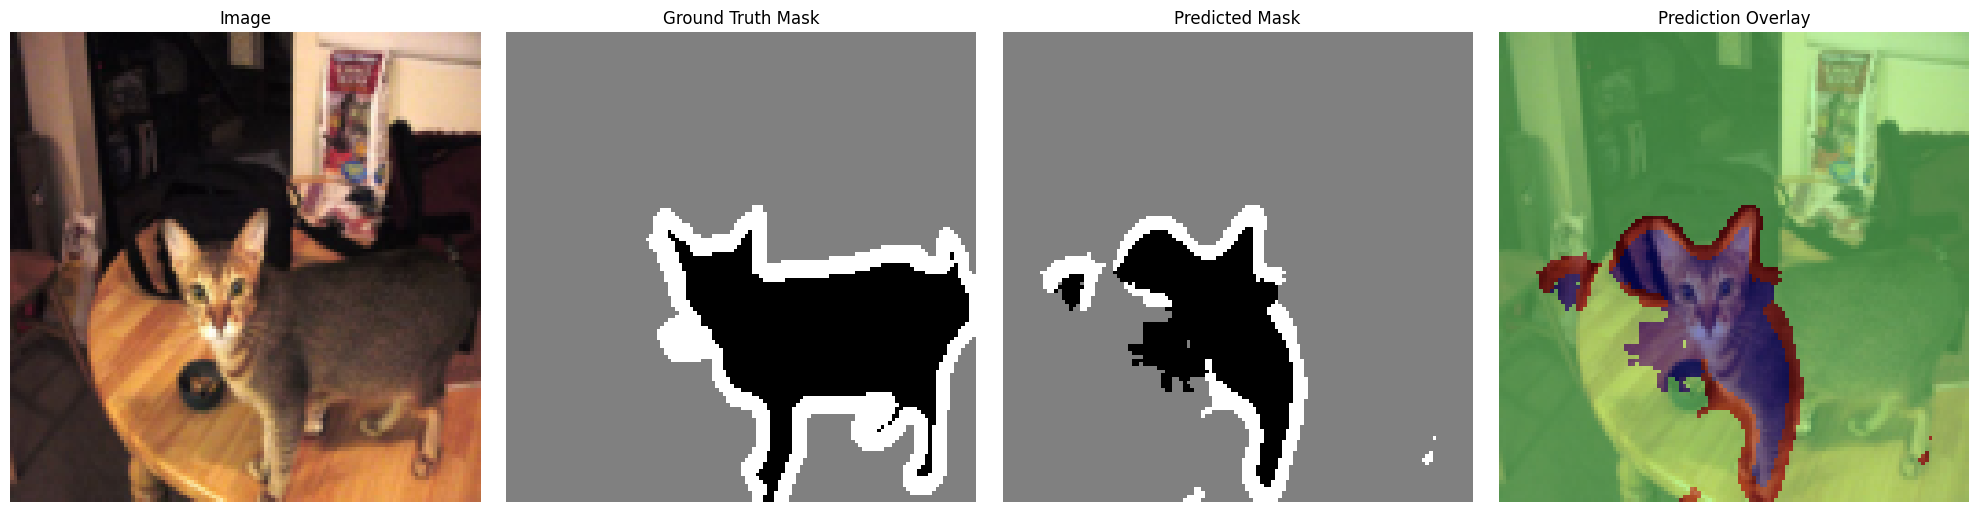

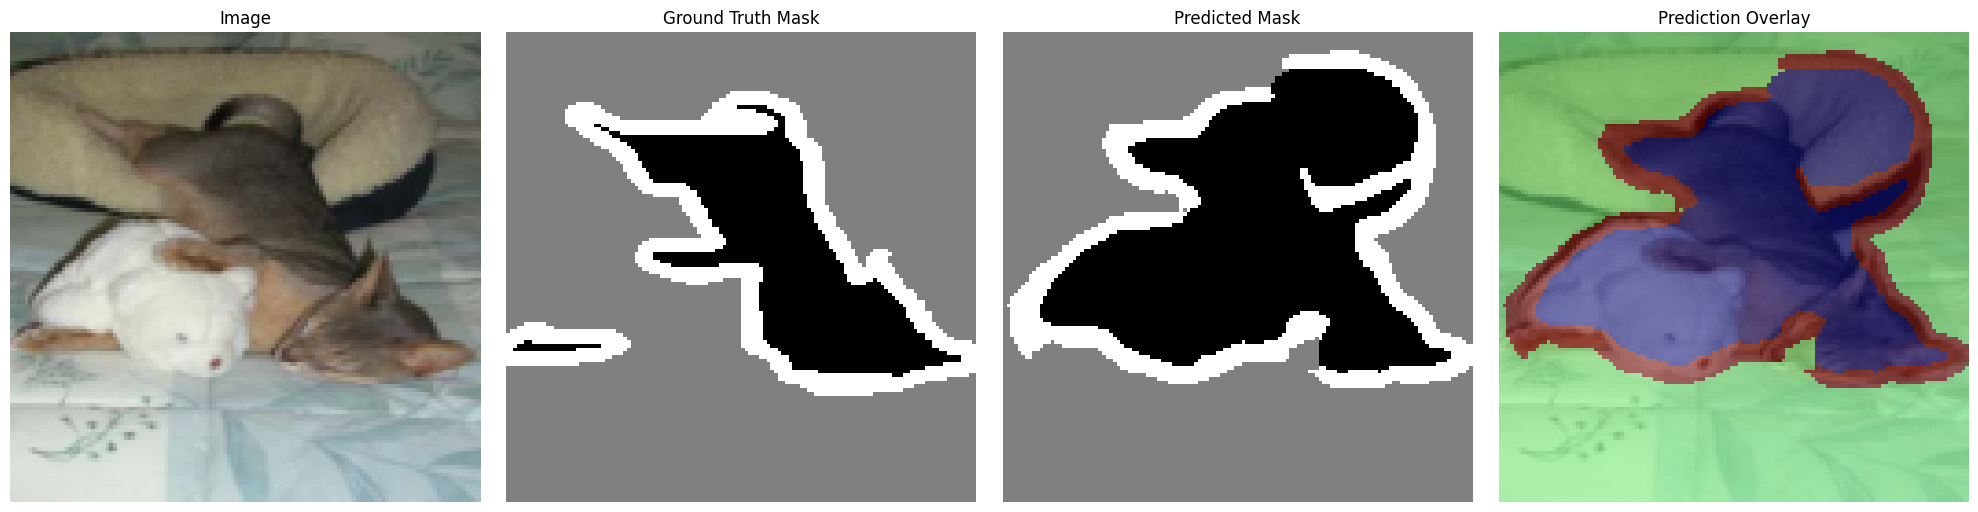

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNET('config/u-net.yaml').to(device)
checkpoint = torch.load('checkpoints/latest.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

test_dataset = OxfordPetsDataset(im_size=128, split='test', num_classes=3)

plot_prediction(model, test_dataset, idx=0, device=device)
plot_prediction(model, test_dataset, idx=5, device=device)